# 🎶🎷 **Sol*pH*<sup>edge</sup>**<br/>pH-dependent molecular solubility predictions made easy

Welcome to SolpH<sup>edge</sup> on Colab.

SolpH<sup>edge</sup> allows you to make AI-enabled pH-dependent solubility predictions for your favourite tyrosine kinase inhibitors.

The results showed herein are presented in the corresponding article: https://doi.org/10.1002/bcp.70166

## 💪 Instructions
Please search the **SMILES** of your compound in https://pubchem.ncbi.nlm.nih.gov

In [1]:
# @title 🚀 Install dependencies...
# @markdown ... by clicking the arrow ▶️ on the left handside of this message.<br/><br/>⚠️ The error occuring when it finishes is expected!!!

from IPython.utils import io

!pip install condacolab -q
import condacolab
condacolab.install_mambaforge()

print('⏳ Just a few more minutes of patience...')
with io.capture_output() as captured:
    !mamba install --quiet -S dask
    !mamba install --quiet -S openbabel -c conda-forge

print('⌛ Almost there!')
with io.capture_output() as captured:
    !pip install --quiet solphedge seaborn adjustText

print('🥳 All done!')
print('⚠️An error will occur, this is normal and expected!')
print('👍 Just carry on with running the next cell with the form.')

Mambaforge has been sunset. It is now identical to Miniforge. Installing Miniforge...


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...
⏳ Just a few more minutes of patience...
⌛ Almost there!
🥳 All done!
⚠️An error will occur, this is normal and expected!
👍 Just carry on with running the next cell with the form.


[21:20:23] Initializing Normalizer


,entrectinib
molecule,CN1CCN(CC1)C2=CC(=C(C=C2)C(=O)NC3=NNC4=C3C=C(C...
ΔlogS,-5.453
solubility (pH=7.4; mM),0.003
solubility (pH=1.0; mM),724.863


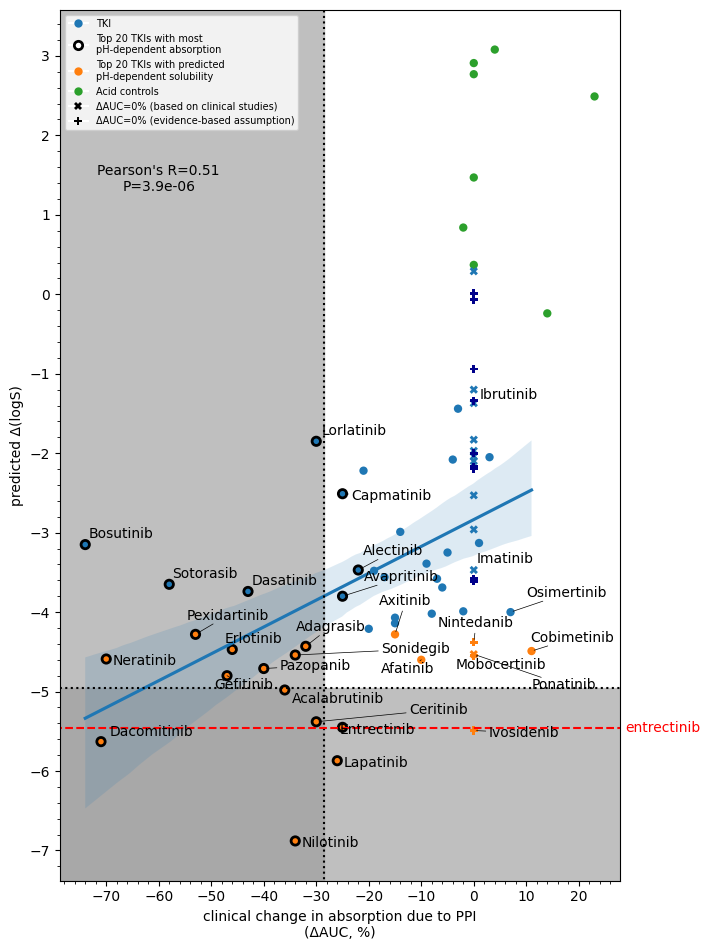

In [1]:
# @title 🔮 Make predictions
# @markdown Paste the **SMILES** in the the input below and choose concentration units to be displayed (default units are nanomolars). <br/>Decimals can also be adjusted for more precision.<br/>Then run it (click the arrow ▶️ on the left handside).<br/>The predictions are shown in a table and in the associated graph.<br/>The molecule name as displayed on the graph can also be modified in the form below.<br/>
SMILES = "CN1CCN(CC1)C2=CC(=C(C=C2)C(=O)NC3=NNC4=C3C=C(C=C4)CC5=CC(=CC(=C5)F)F)NC6CCOCC6" # @param {"type":"string","placeholder":"e.g. CC(=O)OC1=CC=CC=C1C(=O)O"}
name = "entrectinib" # @param {"type":"string"}
units = "mM" # @param {"type":"string","placeholder":"M, mM, uM, nM or pM"}
decimals = 3 # @param {"type":"integer"}

from IPython.display import display

from solphedge import SolpH

solphedge = SolpH()
result = (solphedge.predict(SMILES, out_units=units, round=decimals)
                   .drop(columns=['-logS (pH=7.4)', 'composite -logS (pH=1.0)'])
                   .rename(columns={'delta logS (pH=7.4 - pH=1.0)': 'ΔlogS'})
                   .T
                   .rename(columns={0: name}))

def plot_result(delta_value, name):
    import base64
    from io import BytesIO

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy import stats
    from matplotlib.ticker import AutoMinorLocator, MultipleLocator
    from matplotlib.lines import Line2D
    from adjustText import adjust_text


    data = pd.read_csv(BytesIO(base64.b64decode('Y29udHJvbAluYW1lCWF1YwlvcmlnaW4JZGVsdGENCm5vCUFiZW1hY2ljbGliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS0yLjAwDQpubwlBY2FsYWJydXRpbmliCS0wLjM2CQktNC45OA0Kbm8JQWRhZ3Jhc2liCS0wLjMyCQktNC40Mw0Kbm8JQWZhdGluaWIJLTAuMTAJCS00LjYwDQpubwlBbGVjdGluaWIJLTAuMjIJCS0zLjQ3DQpubwlBbHBlbGlzaWIJLTAuMjEJCS0yLjIyDQpubwlBc2NpbWluaWIJLTAuMDIJCS0zLjk5DQpubwlBdmFwcml0aW5pYgktMC4yNQkJLTMuODANCm5vCUF4aXRpbmliCS0wLjE1CQktNC4yOA0Kbm8JQmluaW1ldGluaWIJMC4wMAliYXNlZCBvbiBjbGluaWNhbCBzdHVkaWVzIHdpdGggUFBJcwktMi41Mw0Kbm8JQm9zdXRpbmliCS0wLjc0CQktMy4xNQ0Kbm8JQ2FwbWF0aW5pYgktMC4yNQkJLTIuNTENCm5vCUNlcml0aW5pYgktMC4zMAkJLTUuMzgNCm5vCUNvYmltZXRpbmliCTAuMTEJCS00LjQ5DQpubwlDcml6b3RpbmliCTAuMDAJYmFzZWQgb24gY2xpbmljYWwgc3R1ZGllcyB3aXRoIFBQSXMJLTEuODMNCm5vCURhYnJhZmVuaWIJMC4wMwkJLTIuMDUNCm5vCURhY29taXRpbmliCS0wLjcxCQktNS42Mw0Kbm8JRGFzYXRpbmliCS0wLjQzCQktMy43NA0Kbm8JRHV2ZWxpc2liCS0wLjE3CQktMy41Ng0Kbm8JRW5hc2lkZW5pYgkwLjAwCWZyb20gYW4gZXZpZGVuY2UtYmFzZWQgYXNzdW1wdGlvbgktMi4yMA0Kbm8JRW5jb3JhZmVuaWIJLTAuMDUJCS0zLjI1DQpubwlFbnRyZWN0aW5pYgktMC4yNQkJLTUuNDUNCm5vCUVyZGFmaXRpbmliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS0yLjE3DQpubwlFcmxvdGluaWIJLTAuNDYJCS00LjQ3DQpubwlGZWRyYXRpbmliCS0wLjIwCQktNC4yMQ0Kbm8JRnV0aWJhdGluaWIJMC4wMAliYXNlZCBvbiBjbGluaWNhbCBzdHVkaWVzIHdpdGggUFBJcwktMS4yMA0Kbm8JR2VmaXRpbmliCS0wLjQ3CQktNC44MA0Kbm8JR2lsdGVyaXRpbmliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS0xLjM0DQpubwlHbGFzZGVnaWIJMC4wMQkJLTMuMTMNCm5vCUlicnV0aW5pYgkwLjAwCWJhc2VkIG9uIGNsaW5pY2FsIHN0dWRpZXMgd2l0aCBQUElzCS0xLjM3DQpubwlJZGVsYWxpc2liCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS0zLjU4DQpubwlJbWF0aW5pYgkwLjAwCWJhc2VkIG9uIGNsaW5pY2FsIHN0dWRpZXMgd2l0aCBQUElzCS0zLjQ3DQpubwlJdm9zaWRlbmliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS01LjQ5DQpubwlMYXBhdGluaWIJLTAuMjYJCS01Ljg3DQpubwlMYXJvdHJlY3RpbmliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS0wLjk0DQpubwlMb3JsYXRpbmliCS0wLjMwCQktMS44NQ0Kbm8JTW9ib2NlcnRpbmliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS00LjU1DQpubwlOZXJhdGluaWIJLTAuNzAJCS00LjU5DQpubwlOaWxvdGluaWIJLTAuMzQJCS02Ljg4DQpubwlOaW50ZWRhbmliCTAuMDAJZnJvbSBhbiBldmlkZW5jZS1iYXNlZCBhc3N1bXB0aW9uCS00LjM4DQpubwlPbHV0YXNpZGVuaWIJMC4wMAlmcm9tIGFuIGV2aWRlbmNlLWJhc2VkIGFzc3VtcHRpb24JLTAuMDcNCm5vCU9zaW1lcnRpbmliCTAuMDcJCS00LjAwDQpubwlQYWxib2NpY2xpYgkwLjAwCWZyb20gYW4gZXZpZGVuY2UtYmFzZWQgYXNzdW1wdGlvbgktMy42MQ0Kbm8JUGF6b3BhbmliCS0wLjQwCQktNC43MQ0Kbm8JUGVtaWdhdGluaWIJLTAuMDgJCS00LjAyDQpubwlQZXhpZGFydGluaWIJLTAuNTMJCS00LjI4DQpubwlQb25hdGluaWIJMC4wMAliYXNlZCBvbiBjbGluaWNhbCBzdHVkaWVzIHdpdGggUFBJcwktNC41Mw0Kbm8JUHJhbHNldGluaWIJLTAuMTUJCS00LjA3DQpubwlSZWdvcmFmZW5pYgktMC4wNAkJLTIuMDgNCm5vCVJpYm9jaWNsaWIJMC4wMAliYXNlZCBvbiBjbGluaWNhbCBzdHVkaWVzIHdpdGggUFBJcwktMi4xMA0Kbm8JUmlwcmV0aW5pYgktMC4wOQkJLTMuMzkNCm5vCVJ1Y2FwYXJpYgkwLjAwCWJhc2VkIG9uIGNsaW5pY2FsIHN0dWRpZXMgd2l0aCBQUElzCS0yLjA0DQpubwlSdXhvbGl0aW5pYgkwLjAwCWJhc2VkIG9uIGNsaW5pY2FsIHN0dWRpZXMgd2l0aCBQUElzCS0yLjk2DQpubwlTZWxwZXJjYXRpbmliCS0wLjA3CQktMy41OA0Kbm8JU29uaWRlZ2liCS0wLjM0CQktNC41NA0Kbm8JU29yYWZlbmliCTAuMDAJYmFzZWQgb24gY2xpbmljYWwgc3R1ZGllcyB3aXRoIFBQSXMJLTEuOTcNCm5vCVNvdG9yYXNpYgktMC41OAkJLTMuNjUNCm5vCVRlcG90aW5pYgktMC4xOQkJLTMuNDgNCm5vCVRyYW1ldGluaWIJMC4wMAlmcm9tIGFuIGV2aWRlbmNlLWJhc2VkIGFzc3VtcHRpb24JMC4wMQ0Kbm8JVHVjYXRpbmliCS0wLjE1CQktNC4xNA0Kbm8JVmFuZGV0YW5pYgktMC4wNgkJLTMuNjkNCm5vCVZlbXVyYWZlbmliCTAuMDAJYmFzZWQgb24gY2xpbmljYWwgc3R1ZGllcyB3aXRoIFBQSXMJMC4yOQ0Kbm8JVmlzbW9kZWdpYgktMC4xNAkJLTIuOTkNCm5vCVphbnVicnV0aW5pYgktMC4wMwkJLTEuNDQNCnllcwlhY2Vub2NvdW1hcm9sCTAuMDAJCTAuMzcNCnllcwlhY2V0eWxzYWxpY3lsaWMgYWNpZAkwLjIzCQkyLjQ5DQp5ZXMJZGljbG9mZW5hYwkwLjA0CQkzLjA4DQp5ZXMJZGlmbHVuaXNhbAkwLjAwCQkyLjc3DQp5ZXMJaWJ1cHJvZmVuCTAuMDAJCTEuNDcNCnllcwlrZXRvcHJvZmVuCTAuMDAJCTIuOTENCnllcwltZWxveGljYW0JMC4xNAkJLTAuMjQNCnllcwlwaGVucHJvY291bW9uCS0wLjAyCQkwLjg0DQo=')), sep='\t')
    data['auc'] *= 100
    data['control'] = data.control.replace({'yes': True, 'no': False})
    data['rank_dlogS'] = data.delta.rank()
    data['rank_AUC'] = data.auc.rank()
    data['AUC0'] = data.auc == 0
    data['AUC0_reported'] = (data.auc == 0) & (data.origin == 'based on clinical studies with PPIs')
    data['AUC0_evidence'] = (data.auc == 0) & (data.origin == 'from an evidence-based assumption')
    N = 20
    MAX_ADJUST_TIME = 5 # seconds
    fig, ax = plt.subplots(figsize=(6.4, 9.6))
    _ = sns.regplot(x='auc',
                    y='delta',
                    data=data.query('not control'),
                    marker='',
                    color='tab:blue',
                    scatter_kws={'edgecolor':'none'},
                    ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('control'),
                        color='tab:green',
                        edgecolor="none",
                        ax=ax)

    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('(not control) and (not AUC0) and (rank_dlogS > @N) and (rank_dlogS > @N)'),
                        marker='o',
                        color='tab:blue',
                        edgecolor="none",
                        ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('(not control) and AUC0 and AUC0_reported and (rank_dlogS > @N) and (rank_dlogS > @N)'),
                        marker='X',
                        # s=15,
                        color='tab:blue',
                        edgecolor="none",
                        ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('(not control) and AUC0 and AUC0_evidence and (rank_dlogS > @N) and (rank_dlogS > @N)'),
                        marker='P',
                        # s=15,
                        color='darkblue',
                        edgecolor="none",
                        ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('rank_dlogS <= @N and not AUC0'),
                        marker='o',
                        color='tab:orange',
                        edgecolor="none",
                        ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('rank_dlogS <= @N and AUC0 and AUC0_reported'),
                        marker='X',
                        color='tab:orange',
                        edgecolor="none",
                        ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('rank_dlogS <= @N and AUC0 and AUC0_evidence'),
                        marker='P',
                        color='tab:orange',
                        edgecolor="none",
                        ax=ax)
    _ = sns.scatterplot(x='auc',
                        y='delta',
                        data=data.query('rank_AUC <= @N'),
                        marker='o',
                        color='none',
                        edgecolor="black",
                        linewidth=2,
                        ax=ax)

    minorLocator = AutoMinorLocator()
    minorLocator2 = MultipleLocator(base=0.2)
    majorLocator = MultipleLocator(base=10)
    majorLocator2 = MultipleLocator(base=1)
    ax.xaxis.set_major_locator(majorLocator)
    ax.xaxis.set_minor_locator(minorLocator)
    ax.yaxis.set_major_locator(majorLocator2)
    ax.yaxis.set_minor_locator(minorLocator2)
    ax.tick_params(which="both", bottom=True, left=True)
    r, pval = stats.pearsonr(y=data.auc, x=data.delta)
    _ = ax.text(-60, 1.3, 'Pearson\'s R=%.2f\nP=%.2g' % (r, pval), ha='center')

    _ = ax.set(xlabel='clinical change in absorption due to PPI\n(ΔAUC, %)', ylabel='predicted Δ(logS)')

    legend_elements = [Line2D([0], [0], marker='o', color='w', label='TKI',
                            markerfacecolor='tab:blue',
                            markeredgecolor=None, markeredgewidth=0, markersize=6),
                    Line2D([0], [0], marker='o', color='w', label=f'Top {N} TKIs with most\npH-dependent absorption',
                            markeredgecolor='black', markeredgewidth=2, markersize=6),
                    Line2D([0], [0], marker='o', color='w', label=f'Top {N} TKIs with predicted\npH-dependent solubility',
                            markerfacecolor='tab:orange',
                            markeredgecolor=None, markeredgewidth=0, markersize=6),
                    Line2D([0], [0], marker='o', color='w', label='Acid controls',
                            markerfacecolor='tab:green',
                            markeredgecolor=None, markeredgewidth=0, markersize=6),
                    Line2D([0], [0], marker='X', color='w', label='ΔAUC=0% (based on clinical studies)',
                            markerfacecolor='black',
                            markeredgecolor=None, markeredgewidth=0, markersize=6),
                    Line2D([0], [0], marker='P', color='w', label='ΔAUC=0% (evidence-based assumption)',
                            markerfacecolor='black',
                            markeredgecolor=None, markeredgewidth=0, markersize=6),
                    ]

    _ = ax.legend(handles=legend_elements, loc='upper left', prop={'size': 7})

    text = data[['auc', 'delta', 'name']]

    text.loc[:, 'name'] = text.name.str.capitalize()

    ax_texts = [ax.text(x, y, s=name)
                for x, y, name in text.values.tolist()
                if name in [# Top 20 as in Figure 2 of the article
                            'Pexidartinib', 'Neratinib', 'Dacomitinib', 'Erlotinib',
                            'Gefitinib', 'Acalabrutinib', 'Ceritinib', 'Nilotinib', 'Entrectinib', 'Lapatinib', 'Ivosidenib',
                            'Pazopanib', 'Adagrasib', 'Sonidegib', 'Axitinib', 'Mobocertinib', 'Ponatinib', 'Cobimetinib',
                            'Nintedanib', 'Osimertinib', 'Afatinib',
                            # Other TKIs
                            'Bosutinib', 'Sotorasib', 'Dasatinib', 'Lorlatinib', 'Capmatinib', 'Alectinib', 'Avapritinib',
                            'Imatinib', 'Ibrutinib'
                            ]]

    _ = adjust_text(texts=ax_texts,
                    arrowprops=dict(arrowstyle="-", color='k', lw=0.5),
                    ax=ax,
                    time_lim=MAX_ADJUST_TIME)

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    _ = ax.fill_between(x=[-100, -28.5], y1=-10, y2=10, alpha=1, color='#BFBFBF', zorder=-3)
    _ = ax.fill_between(x=[-100, 100], y1=-10, y2=-4.95, alpha=1, color='#BFBFBF', zorder=-3)
    _ = ax.fill_between(x=[-100, -28.5], y1=-10, y2=-4.95, alpha=1, color='#A8A8A8', zorder=0)

    _ = ax.vlines(x=-28.5, ymin=-10, ymax=10, colors='black', linestyle='dotted')
    _ = ax.hlines(y=-4.95, xmin=-100, xmax=100, colors='black', linestyle='dotted')

    # Prediction
    _ = ax.hlines(y=result.loc['ΔlogS'].item(), xmin=-100, xmax=100, colors='red', linestyle='dashed')

    _ = ax.set_xlim(xlim)
    _ = ax.set_ylim(ylim)

    plt.tight_layout()

    _ = ax.text(x=ax.get_xlim()[1] + 1, y=delta_value, s=name, color='red', ha='left', va='center')

plot_result(result.loc['ΔlogS'].item(), name)
display(result)
